# Time series analysis

In [8]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels

## Overview

In this notebook, we analyse time resolved data.

We have data of cells where the location of our gene of interes oscillates between the nucleus and the cytoplasm. Our question is **What is the frequency of the oscillations?**

We have a total of 16 time points with a temporal spacing of 30 min.
The background of the images was measured to be 4700.

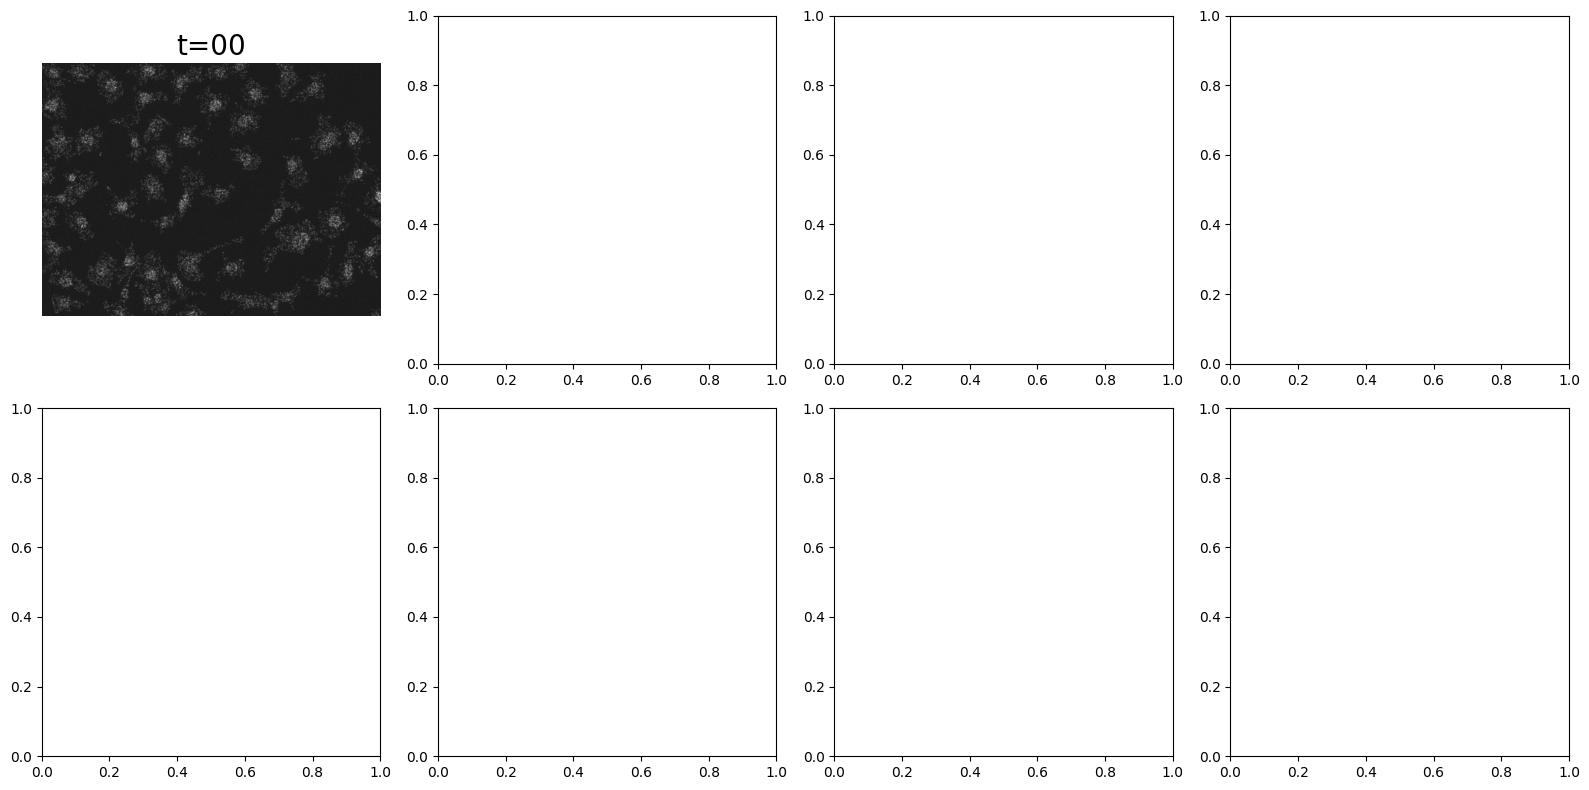

In [10]:
image_folder = Path("../../_static/images/quant/03_time_series/images/")
image_paths = sorted(image_folder.glob("*.tif"))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, path in zip(axes.flat, image_paths[:8]):
    image = tifffile.imread(path)[2, :, :]
    tp = path.stem.split("_t")[1].split("_")[0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"t={tp}", fontsize=20)
    ax.axis("off")

plt.tight_layout()
plt.show()

These are the first eight time points.

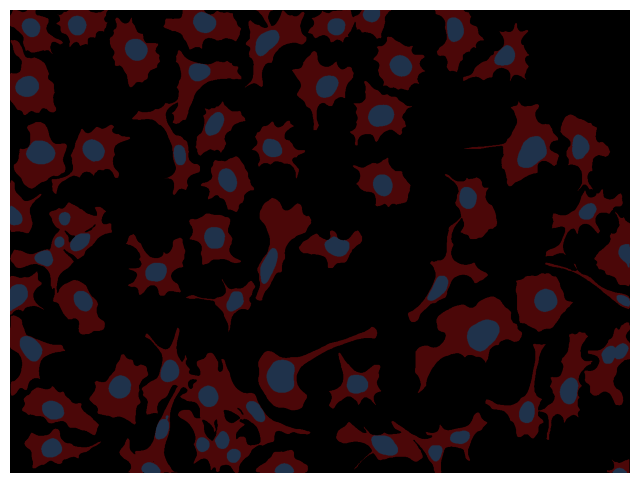

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
mask_cells = tifffile.imread(
    "../../_static/images/quant/03_time_series/masks/F01_1615_cells.TIF"
)
mask_nuclei = tifffile.imread(
    "../../_static/images/quant/03_time_series/masks/F01_1615_nuc.TIF"
)

overlay_labels(label_mask=[mask_cells, mask_nuclei])

This are the two label masks for the nuclei and the cells.

### ✍️ Exercise: Perform this analysis

1. For the first time point (image) use `regionprops_table` to measure the expression level of each nucleus. Follow the steps of the previous notebooks.
2. Perform proper quality control and check that the measurements do not contain artefacts.
3. Set up batch processing to analyse all 16 images. Remember to keep track of where the data came from. Add a column `time` that contains the time at which the image was taken (e.g. 0, 0.5, 1, 1.5) (the unit is hours).
4. Use `sns.lineplot` to visualise the oscillations of individual cell as well as the average oscillations, and estimate the frequency.
5. BONUS: Instead of nuclear intensity, calculate the ratio of nuclear/cytoplasmic intensity.

## Solution

### 1. Measure nuclear intensity
First, we measure the intesities of all the nuclei in the image.

Load the first time point.

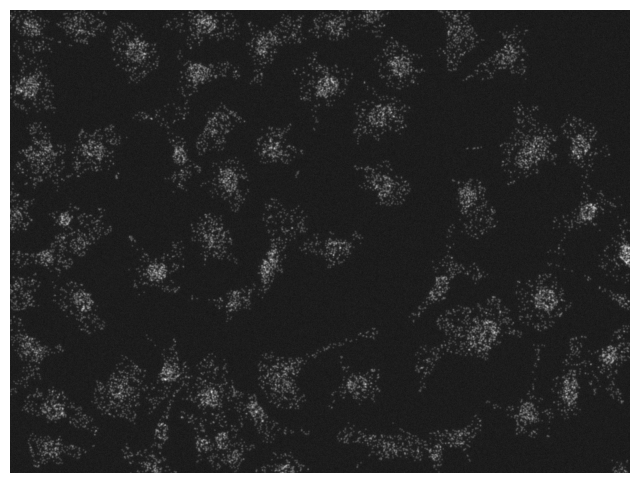

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
image_path = image_paths[0]

image_t0 = tifffile.imread(image_path)[2, :, :]
overlay_labels(image=image_t0)

Remove boundary objects.

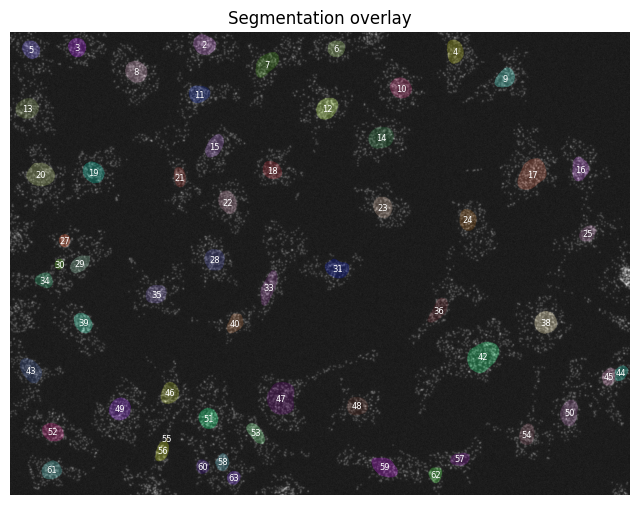

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [16]:
mask_nuclei = skimage.segmentation.clear_border(mask_nuclei)
overlay_labels(image=image_t0, label_mask=mask_nuclei)

Measure intesities with `regionprops_table` ans save measurements as `DataFrame`.

In [17]:
properties = ["area", "intensity_mean", "label"]
props = skimage.measure.regionprops_table(
    mask_nuclei, intensity_image=image_t0, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1867.0     1219.606856      2
1   1429.0      949.058782      3
2   1679.0      891.475878      4
3   1355.0     1117.744649      5
4   1232.0     1028.202110      6
5   2112.0     1059.398674      7
6   1954.0     1140.899693      8
7   1572.0     1025.725191      9
8   1862.0     1176.601504     10
9   1554.0     1249.428571     11
10  1945.0     1325.883290     12
11  1947.0     1274.606574     13
12  2306.0     1073.635299     14
13  1597.0      931.844083     15
14  1647.0     1237.388585     16
15  3382.0     1080.040509     17
16  1439.0     1091.980542     18
17  1881.0     1090.993620     19
18  2693.0      977.158188     20
19  1028.0     1240.612840     21
20  1715.0     1213.583673     22
21  1697.0     1083.809075     23
22  1540.0     1165.322727     24
23  1087.0     1456.276909     25
24   619.0     1488.179321     27
25  1846.0      998.769772     28
26  1330.0      888.450376     29
27   438.0      806.287671     30
28  1824.0    

Subtract background intensity from measurements. Background was measured to 460.

In [29]:
background_intensity = 460
df_nuc["intensity_bg_cor"] = df_nuc["intensity_mean"] - background_intensity
print(df_nuc["intensity_bg_cor"].head())
print(
    "\nAre there any negative values after background subtraction?",
    (df_nuc["intensity_bg_cor"] < 0).any(),
)

0    759.606856
1    489.058782
2    431.475878
3    657.744649
4    568.202110
Name: intensity_bg_cor, dtype: float64

Are there any negative values after background subtraction? False


Add `time` column.

In [30]:
time_point = image_path.stem.split("_")[2]
time = float(time_point[1:]) * 0.5
print(time)

0.0


In [31]:
df_nuc["time"] = time

### 2. Quality control

<Axes: xlabel='intensity_bg_cor', ylabel='Count'>

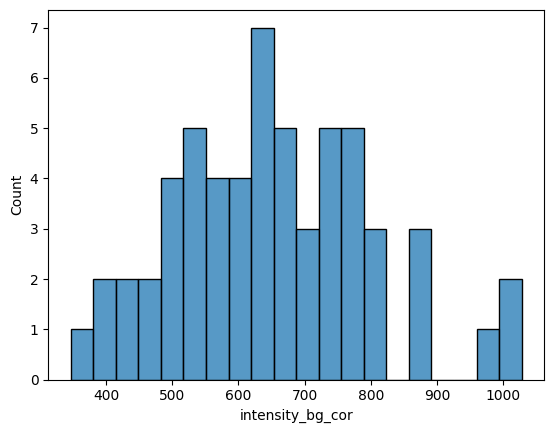

In [32]:
sns.histplot(
    data=df_nuc,
    x="intensity_bg_cor",
    bins=20,
)

Seems unsuspicious.

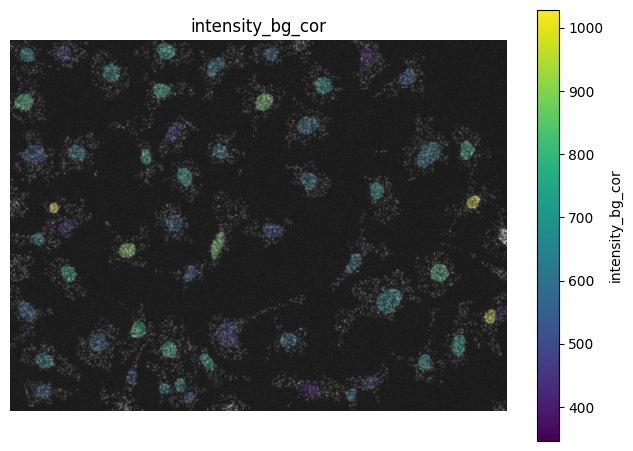

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'intensity_bg_cor'}>)

In [33]:
overlay_labels(
    image=image_t0,
    label_mask=mask_nuclei,
    df=df_nuc,
    id_col="label",
    measurement_col="intensity_bg_cor",
)

Looks fine.

### Batch processing

In [ ]:
list_df = []

for image_path in image_paths:
    image = tifffile.imread(image_path)
    props = skimage.measure.regionprops_table(
        mask_nuclei, intensity_image=image, properties=properties
    )
    sdf = pd.DataFrame(props)
    sdf["intensity_bg_cor"] = sdf["intensity_mean"] - background_intensity
    time_point = image_path.stem.split("_")[2]
    time = float(time_point[1:]) * 0.5
    sdf["time"] = time
    list_df.append(sdf)

df = pd.concat(list_df)
print(df)

### Plotting

In [ ]:
df.groupby(["label", "time"])["intensity_bg_cor"].mean().reset_index()

In [ ]:
sns.lineplot(data=df, x="time", y="intensity_bg_cor", errorbar="sd")

In [ ]:
sns.lineplot(data=df, x="time", y="intensity_bg_cor", hue="label")